In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score , root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from src.linear_regression_from_scratch import LinearRegression as LinearRegressionFromScratch

from src.preprocessing import (
    encode_categorical_features,
    data_splitting,
    scale_features,
)



In [150]:
df = pd.read_csv(r"..\dataset\student_data.csv")

X = df.drop("G3" , axis= 1)
y = df["G3"]

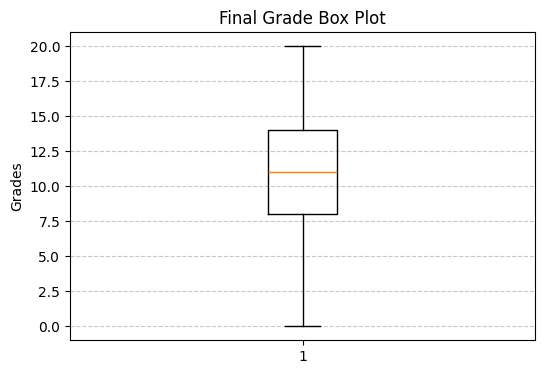

In [151]:
plt.figure(figsize=(6, 4))
plt.boxplot(y)

plt.title('Final Grade Box Plot')
plt.ylabel('Grades')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [152]:
X_encoded = encode_categorical_features(X)

In [153]:
x_train , x_test , y_train , y_test = data_splitting(X_encoded , y)

In [154]:
X_train_scaled, X_test_scaled = scale_features(x_train , x_test )

In [155]:
Sklearn_LR_model = LinearRegression()

Sklearn_LR_model.fit(X_train_scaled , y_train)

y_pred = Sklearn_LR_model.predict(X_test_scaled)

y_pred


array([ 9.91960314,  9.66816588, 11.25717929,  8.67943341, 20.09297115,
       14.7532737 , 10.69926795, 10.23805204,  2.91460884,  6.65616507,
       17.02544636, 13.08174535,  6.50458456,  8.08002857,  8.5387411 ,
       16.17749416, 12.03027173, 12.47069975, 11.59924303, 11.29999424,
       20.25749563,  6.59935122, 10.87111968,  3.481618  , 10.08709113,
       12.0295807 , 15.03871251,  5.15314885, 11.09063702, -0.75549693,
        8.68075114,  8.78815143, 11.16842927, 11.76162322,  9.02883941,
        9.54924528,  8.86464995,  7.9679695 , 13.74424728, 11.6600537 ,
        0.87846412,  7.94982564,  7.30639768, 14.42513651,  3.94850216,
        7.33617993,  7.92689334, 13.7707704 ,  8.82935218, 10.51450178,
        8.05148881, 13.70306914, 19.00120645,  6.1101012 , 11.11284936,
       17.35338494, 10.91628321,  0.56402085,  8.28705478,  6.551596  ,
       18.38937296, 10.10330221, 10.47989145, 12.33321392, 12.55319092,
       11.51766746, 12.64216007, -0.31145361, 11.31928728, 12.08

In [156]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [157]:
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1.22
MSE : 3.92
RMSE: 1.98
R²  : 0.8237


In [158]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.round(2)
})

print(comparison.head(10))

   Actual  Predicted
0      10       9.92
1      10       9.67
2      11      11.26
3      10       8.68
4      19      20.09
5      15      14.75
6      10      10.70
7      10      10.24
8       0       2.91
9       6       6.66


In [159]:
My_LR_scratch_model = LinearRegressionFromScratch(epochs=300)

My_LR_scratch_model.fit(X_train_scaled , y_train)

y_scratch_pred = My_LR_scratch_model.predict(X_test_scaled)

y_scratch_pred

Epoch 100: cost = 5.555842097401045
Epoch 200: cost = 3.3503203500043575
Epoch 300: cost = 3.2430527419876096


array([10.24778708,  9.81849343, 11.6742728 ,  8.38520021, 19.9754909 ,
       14.55900866, 10.64719648,  9.88794231,  2.67371794,  6.95161013,
       16.78347588, 12.54518574,  6.5720097 ,  7.47578014,  8.38439545,
       16.39522156, 11.69381216, 12.46468842, 11.83205582, 11.15634491,
       19.86962214,  6.20095962, 10.63568796,  3.06573094, 10.03494664,
       12.21576413, 15.18770548,  5.13074423, 11.00616055,  0.58361571,
        8.27706837,  8.98065832, 11.26075976, 11.17474686,  8.93817729,
        9.9226244 ,  8.88970864,  7.65669892, 13.06011339, 12.21713661,
        2.67615566,  7.67685221,  6.69532733, 14.57523311,  3.44550223,
        7.67844933,  8.54682635, 13.65483157,  7.99879948,  9.89677422,
        7.46936493, 13.68717541, 18.85370758,  6.20793772, 11.37306776,
       17.16744283, 11.29927857,  1.95730699,  7.61776511,  5.27788735,
       18.19186959,  9.88120708, 10.28361044, 12.34798512, 12.71611195,
       11.39950696, 12.4375225 ,  1.11725217, 11.66885091, 12.23

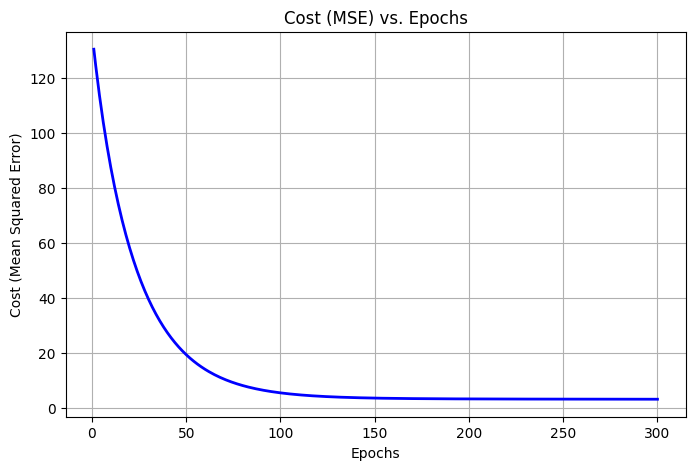

In [160]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, My_LR_scratch_model.epochs + 1), My_LR_scratch_model.cost_history, color="blue", linewidth=2)
plt.title("Cost (MSE) vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost (Mean Squared Error)")
plt.grid(True)
plt.show()


# Observation: The cost decreases rapidly during the early epochs and stabilizes after approximately 200 epochs. Therefore, training for 300 epochs provides sufficient convergence without unnecessary computation.

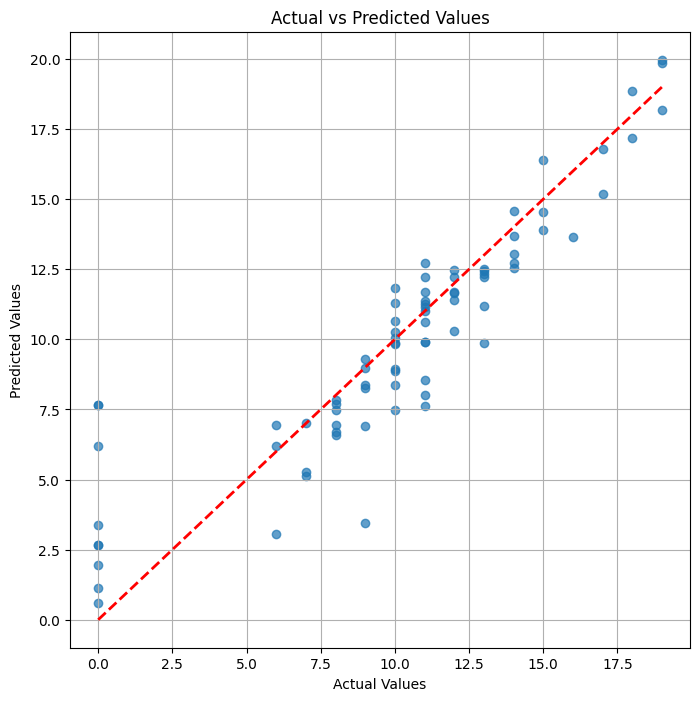

In [161]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_scratch_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.grid(True)

plt.show()

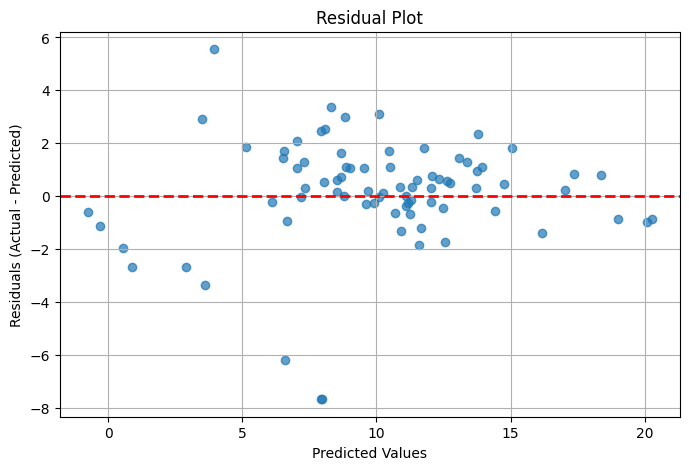

In [162]:
residuals = y_test - y_scratch_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")

plt.grid(True)

plt.show()

In [163]:
mae = mean_absolute_error(y_test, y_scratch_pred)
mse = mean_squared_error(y_test, y_scratch_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_scratch_pred)

In [164]:
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1.39
MSE : 4.24
RMSE: 2.06
R²  : 0.8090


In [165]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_scratch_pred.round(2)
})

print(comparison.head(10))

   Actual  Predicted
0      10      10.25
1      10       9.82
2      11      11.67
3      10       8.39
4      19      19.98
5      15      14.56
6      10      10.65
7      10       9.89
8       0       2.67
9       6       6.95


In [166]:
comparison = pd.DataFrame({
    "Sklearn LR": y_pred.round(2),
    "My LR From Scratch": y_scratch_pred.round(2)
})

print(comparison.head(10))

   Sklearn LR  My LR From Scratch
0        9.92               10.25
1        9.67                9.82
2       11.26               11.67
3        8.68                8.39
4       20.09               19.98
5       14.75               14.56
6       10.70               10.65
7       10.24                9.89
8        2.91                2.67
9        6.66                6.95
